In [ ]:
# enable automatic reloading of modules
%load_ext autoreload
%autoreload 2
from utils import load_twitter
from CD import CD
import matplotlib.pyplot as plt
import networkx as nx
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
(n_tw, s_tw, A_tw, G_tw, L_tw) = load_twitter()
# generate the edge 'weight' as the absolute difference of the two node values in s_tw
# For the existing edges in G_tw, set the weight as the absolute difference of the two node values in s_tw
for u, v in G_tw.edges():
    G_tw[u][v]['weight'] = float(abs(s_tw[u].item() - s_tw[v].item()))

G_new, new_edges = CD(G_tw, 10, s_tw, weight_attr='weight').coordinate_descent()
print(f"Number of new edges: {len(new_edges)}")
print(new_edges)
#[(18, 196), (40, 411), (27, 71), (327, 457), (199, 225), (82, 166), (89, 175), (197, 488), (199, 396), (82, 341)]
#[(71, 196), (18, 327), (82, 225), (90, 175), (197, 411), (199, 477), (39, 40), (27, 391), (161, 522), (199, 205)]


100%|██████████| 10/10 [00:03<00:00,  3.24it/s]

Number of new edges: 10
[(71, 196), (18, 327), (82, 225), (90, 175), (197, 411), (199, 477), (39, 40), (27, 391), (161, 522), (199, 205)]


In [37]:
def draw_graph(G_new, new_edges, title):
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G_new, iterations=20, weight='None')
    nx.draw_networkx_nodes(G_new, pos, node_size=30, node_color='blue', alpha=0.6)
    if new_edges is None:
        nx.draw_networkx_edges(G_new, pos, edge_color='grey', width=0.5, alpha=0.6)
    else:
        new_edges_set = {tuple(sorted(ne)) for ne in new_edges}
        existing_edges = [e for e in G_new.edges() if tuple(sorted(e)) not in new_edges_set]
        valid_new_edges = [ne for ne in new_edges if G_new.has_edge(*ne)]
        nx.draw_networkx_edges(G_new, pos, edgelist=existing_edges, edge_color='grey', width=0.5, alpha=0.6)
        if valid_new_edges:
            nx.draw_networkx_edges(G_new, pos, edgelist=valid_new_edges, edge_color='red', width=1.5, alpha=0.8)
        elif new_edges:
            print("Warning: None of the provided 'new_edges' exist in the graph G_new.")
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
graph_file = '../../output/results-theta=0.5/Referendum_/graph.gml'
G = nx.read_gml(graph_file)
G_new, new_edges_ele = CD(G, 10, innate_opinion_attr='polarity', weight_attr='weight').coordinate_descent()
print(f"Number of new edges: {len(new_edges_ele)}")
print(new_edges_ele)
#[(42, 172), (2272, 2378), (462, 1900), (308, 1433), (1206, 2583), (903, 2774), (206, 1156), (154, 966), (1773, 2630), (1052, 2116)]
# [(126, 129), (127, 202), (172, 258), (185, 509), (317, 528), (520, 993), (550, 1006), (581, 993), (129, 622), (661, 1006)]

Coordinate Descent: 100%|██████████| 10/10 [00:58<00:00,  5.86s/it]

Number of new edges: 10
[(126, 129), (127, 202), (172, 258), (185, 509), (317, 528), (520, 993), (550, 1006), (581, 993), (129, 622), (661, 1006)]


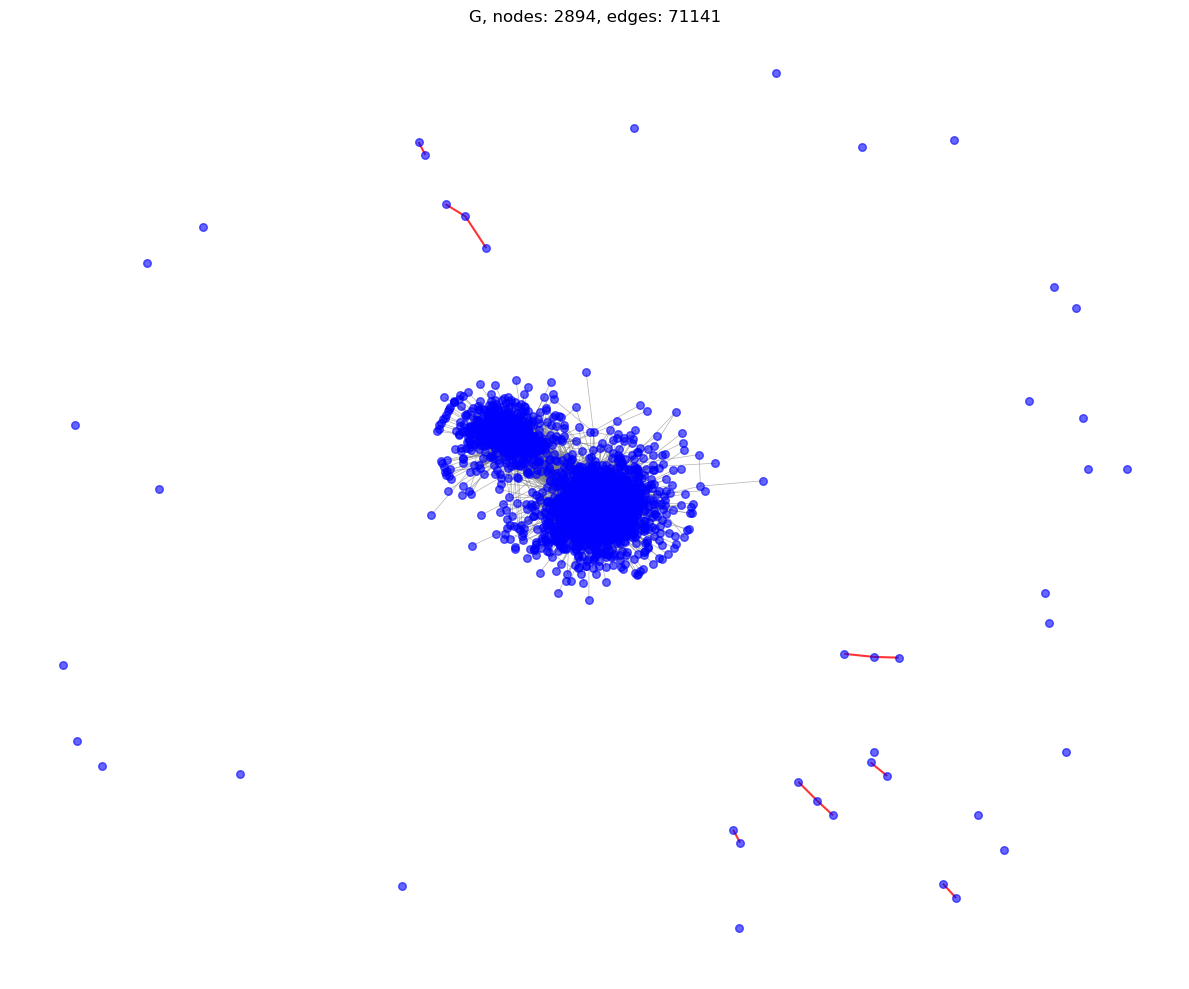

In [55]:
draw_graph(G_new, new_edges_ele, f"G, nodes: {G_new.number_of_nodes()}, edges: {G_new.number_of_edges()}")